In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti
import event_io as eio


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import pickle

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )
importlib.reload( eio )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
# This allow both dict.key and dict['key'] syntax
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")

    def __setattr__(self, key, value):
        self[key] = value

    def __delattr__(self, key):
        try:
            del self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")



In [3]:
%%time
importlib.reload( futi )
importlib.reload( nuti )
nsteps=None
start_date=None
super_lat_range = [-90.,90.]  #[-85,-30]
case, process_ncdata  = 'cam77_dyamond1_prod1'    , False

A = futi.read_case( case=case, nsteps=nsteps, start_date=start_date , super_lat_range=super_lat_range ) # , nsteps = 31*8 )

time, zlev, lat, lon = A.time, A.zlev, A.lat, A.lon

GWP_vars_file=f"{case}_src_fit_vars_2.nc"

GWP = xr.open_dataset( GWP_vars_file )

  nsteps=247 
/glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-01-10800.nc /glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-31-75600.nc
 Dataset opened  , dtype of U,V float32 float32 
 Dataset opened  trimmed. -89.76 to  89.76 
Read subsetted X w open_mfdata_set  155.5601 seconds
extracted upwp,...U,V,T etc  111.6414 seconds
Vorticity calc  4.9481 seconds
rho geopht pint ... calc  37.2666 seconds
rho calc ... epwp  8.6814 seconds
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
tilting calc  10.4032 seconds
this is Sphere_grad_vec in numerical_utils in HiRes_ana
dlat has been adjusted to account for FUCKED UP CRAPPY fv1x1 SCRIP FILE IN CESMDATA INPUTs!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
frontogenesis calc  24.6457 seconds
stability calc  3.5071 seconds
CPU times: user 1min 16s, sys: 1min 12s, total: 2min 28s
Wall time: 6min 13s


In [4]:
%%time

case='xympas-DynZlZs-tilt-x02'
dates='2016-08-*'
foo=f"/glade/derecho/scratch/juliob/archive/GW_UnitTest/{case}/{case}.h.{dates}.nc"
Xgw=xr.open_mfdataset( foo , data_vars='different', coords='different', compat='no_conflicts' )


ny = Xgw.sizes["ny"]
nx = Xgw.sizes["nx"]

j = np.arange(ny).repeat(nx)
i = np.tile(np.arange(nx), ny)

X2 = (
    Xgw.assign_coords(_j=("ncol", j), _i=("ncol", i))     # mapping ncol -> (j,i)
     .set_index(ncol=("_j", "_i"))
     .unstack("ncol")
     .rename({"_j": "ny", "_i": "nx"})
     .assign_coords(ny=Xgw["lat_R"], nx=Xgw["lon_R"])        # put real coords on axes
)


X2['lat']=Xgw['lat_R']
X2['lon']=Xgw['lon_R']
Xgw=X2

CPU times: user 29.8 s, sys: 5.66 s, total: 35.5 s
Wall time: 2min 46s


In [5]:
%%time
xpwp_src_1_2  = Xgw.XPWP_SRC_1.values
xpwp_src_3_2  = Xgw.XPWP_SRC_3.values
xpwp_src_3_2[:,-1,:]=0.


CPU times: user 4.78 s, sys: 786 ms, total: 5.57 s
Wall time: 24.6 s


In [6]:
%%time
lat1,lon1=Xgw.lat.values, Xgw.lon.values

k_steer_1  = Xgw.K_STEER_MOVMTN.values
k_launch_1 = Xgw.K_LAUNCH_MOVMTN.values
p_steer_1  = Xgw.P_STEER_MOVMTN.values
p_launch_1 = Xgw.P_LAUNCH_MOVMTN.values
pmid_mm_1 = Xgw.PMID_MOVMTN.values
pmid_1    = Xgw.PMID.values

xpwp_src_1_1  = Xgw.XPWP_SRC_1.values
xpwp_src_3_1  = Xgw.XPWP_SRC_3.values

tau_mm_1 = Xgw.TAU_MOVMTN.values
sgh=Xgw.SGH.values

xpwp_src_3_1[:,-1,:]=0.

z_steer_1 = -7_000. * np.log( p_steer_1 / 100_000. )
z_launch_1 = -7_000. * np.log( p_launch_1 / 100_000. )

usteer_1  = Xgw.USTEER_MOVMTN.values
ulaunch_1 = Xgw.ULAUNCH_MOVMTN.values

vsteer_1  = Xgw.VSTEER_MOVMTN.values
vlaunch_1 = Xgw.VLAUNCH_MOVMTN.values

uwavef_1 = Xgw.UWAVEF_MOVMTN.values
vwavef_1 = Xgw.VWAVEF_MOVMTN.values


CPU times: user 41.4 s, sys: 28.5 s, total: 1min 9s
Wall time: 4min 9s


0.0 0.0


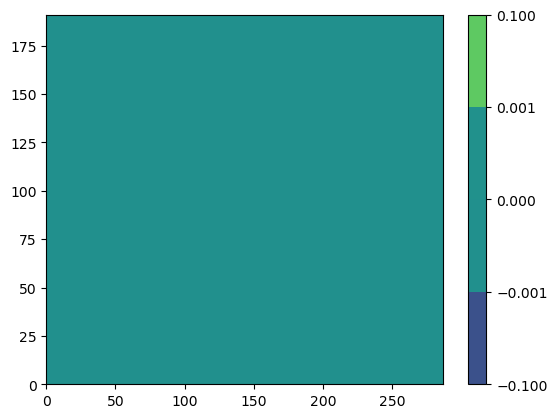

In [7]:

print( (xpwp_src_3_2-xpwp_src_3_1).min(), (xpwp_src_3_2-xpwp_src_3_1).max() ) 
plt.contourf( (xpwp_src_3_2-xpwp_src_3_1).mean(axis=0), levels=[-.1,-.001,0,.001,.1] ) 
plt.colorbar()


In [8]:
k_steer_1.shape

(247, 192, 288)

In [9]:
k_steer=GWP.k_steer.values

In [10]:
GWP

<xarray.Dataset> Size: 765MB
Dimensions:     (time: 247, lat: 192, lon: 288, lev: 58)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2016-08-01 ... 2016-08-31T18:00:00
  * lat         (lat) float64 2kB -89.76 -89.06 -88.12 ... 88.12 89.06 89.76
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev         (lev) float64 464B 4.112e+04 3.687e+04 3.323e+04 ... 106.2 35.0
Data variables:
    epwp_zl     (time, lat, lon) float32 55MB ...
    tilt_zs_zl  (time, lat, lon) float64 109MB ...
    tilt_zg_zs  (time, lat, lon) float64 109MB ...
    tilt_zs     (time, lat, lon) float64 109MB ...
    tilt_zl     (time, lat, lon) float64 109MB ...
    k_launch    (time, lat, lon) int64 109MB ...
    k_steer     (time, lat, lon) int64 109MB 38 38 38 38 38 ... 28 27 27 27 28
    precl       (time, lat, lon) float32 55MB ...

(247, 192, 288)


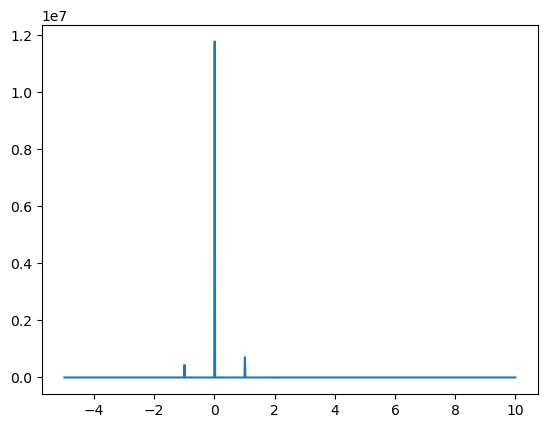

In [11]:
del_k_steer = k_steer - (k_steer_1 -1)

print( del_k_steer.shape )


#plt.plot( del_k_steer[0, 5:-5,:].flatten() ,'.')

hh = np.histogram( del_k_steer[:, 5:-5,:].flatten(), bins=np.linspace(-5,10,num=1001 ) )

plt.plot( hh[1][1:],hh[0] )


In [12]:
tilt_zs_zl = GWP.tilt_zs_zl.values
tilt_zl = GWP.tilt_zl.values
tilt_zs = GWP.tilt_zs.values
epwp_zl = GWP.epwp_zl.values
precl = GWP.precl.values

In [13]:
print(A.topo_file)

/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc


In [14]:
Topo=xr.open_dataset( A.topo_file )
sgh=Topo.SGH.values

In [15]:

#mask=sgh<10.

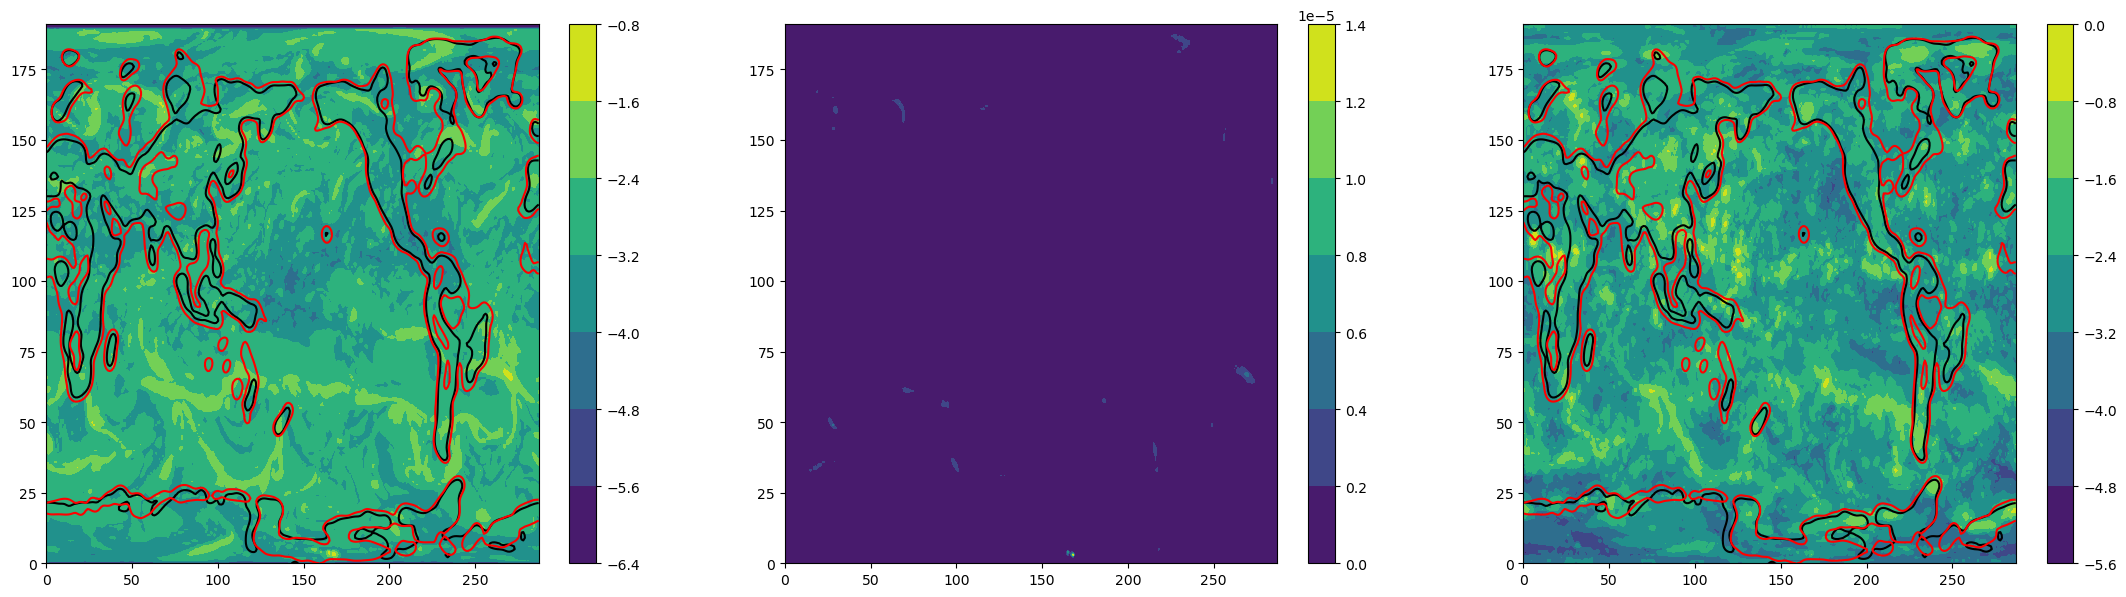

In [16]:
from scipy.ndimage import gaussian_filter

#smoothed = gaussian_filter(field, sigma=2)  # sigma in grid points

sgh_smooth = gaussian_filter( sgh, sigma=2) 
mxd_smooth = gaussian_filter( A.mxdis, sigma=2) 
t=100
#xpwp_src_3_1.shape
fig,axs=plt.subplots( 1,3, figsize=(3*9,7) ) 
ax=axs[0]
co=ax.contourf(  np.log10(xpwp_src_3_1[t,:,:]+1e-6) )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[1]
co=ax.contourf(   tilt_zs_zl[t,:,:] )
plt.colorbar( co )
ax=axs[2]
co=ax.contourf(   np.log10(epwp_zl[t,:,:]) )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )


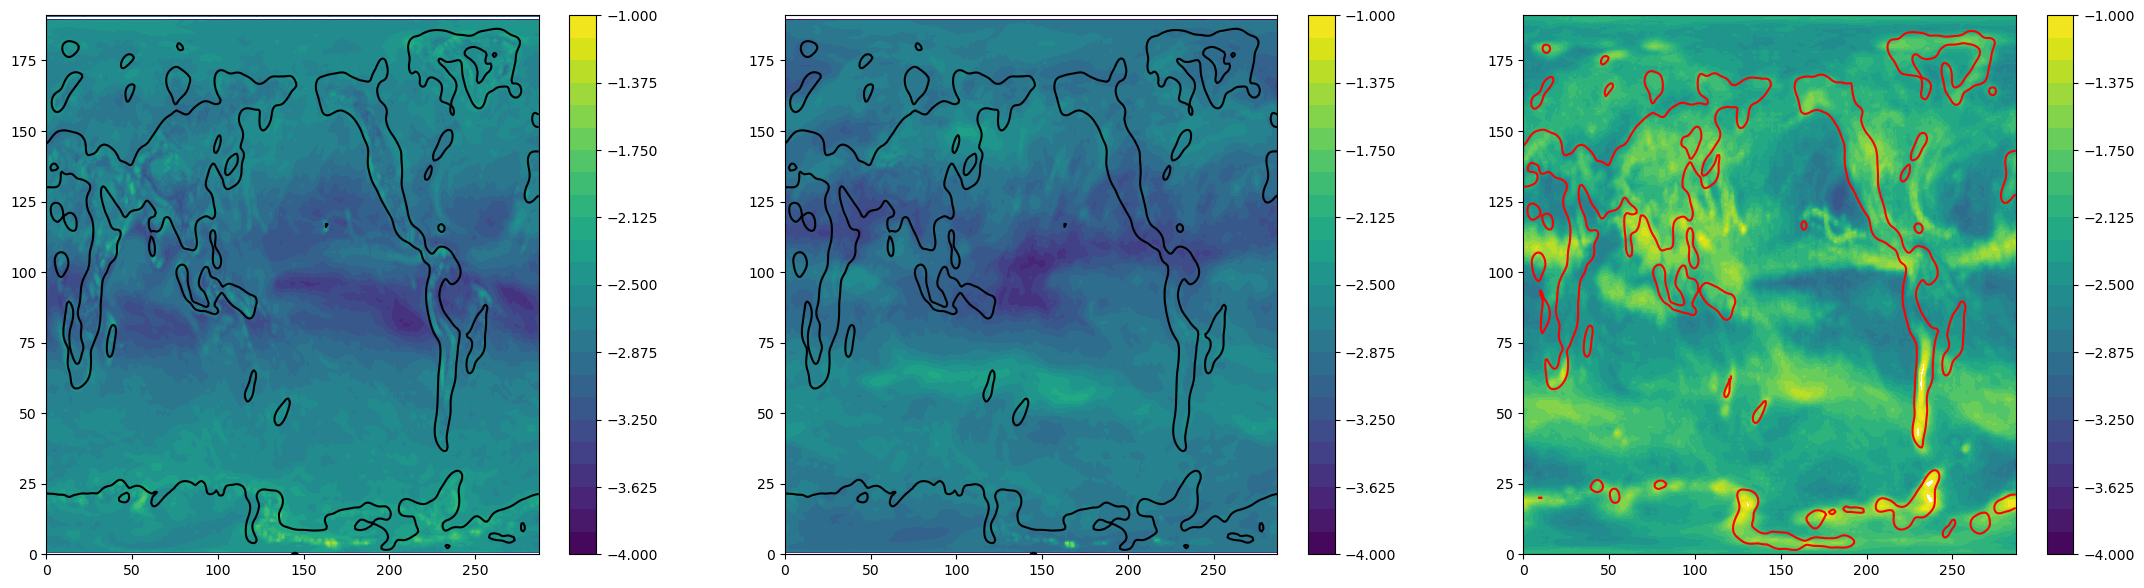

In [17]:
from scipy.ndimage import gaussian_filter

#smoothed = gaussian_filter(field, sigma=2)  # sigma in grid points

logmflv = np.linspace( -6,-1, num=25 )
logmflv = np.linspace( -4,-1, num=25 )

sgh_smooth = gaussian_filter( sgh, sigma=2) 
#mxd_smooth = gaussian_filter( A.mxdis, sigma=1) 
t=100
t0,t1=0,247 #100,100
#xpwp_src_3_1.shape
fig,axs=plt.subplots( 1,3, figsize=(3*9,7) ) 
ax=axs[0]
co=ax.contourf(  np.log10( xpwp_src_1_2[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[1]
co=ax.contourf(  np.log10( xpwp_src_3_2[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#co=ax.contourf(   tilt_zs_zl[t0:t1+1,:,:].mean( axis=0) )
plt.colorbar( co )
ax=axs[2]
co=ax.contourf(   np.log10( epwp_zl[t0:t1+1,:,:].mean( axis=0)  ) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200, 2000] , colors='red' )
plt.colorbar( co )


In [18]:
lat=GWP.lat.values
print( ny, nx )
latyx=np.tile( lat[:,None], (1,nx) )
print(latyx.shape)

mask=( mxd_smooth<200.) & (latyx >=-60.) & (latyx<=-40)
mask=( mxd_smooth<200.) & (latyx >=-80.) & (latyx<=-20)

maskN=( mxd_smooth<200.) & (latyx <=80.) & (latyx>=0)


192 288
(192, 288)


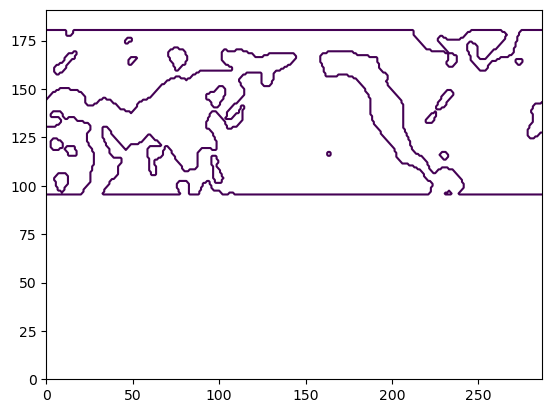

In [19]:
plt.contour( maskN )

In [20]:

case, process_ncdata  = 'cam77_dyamond1_prod1'    , False
GWP_vars_file=f"{case}_src_fit_vars_4.nc"
print( GWP_vars_file )
GWP = xr.open_dataset( GWP_vars_file )


tilt_zg_zs=GWP.tilt_zg_zs.values
tilt_zs_zl=GWP.tilt_zs_zl.values
tilt_zs=GWP.tilt_zs.values
tilt_zl=GWP.tilt_zl.values
zeta_zs=GWP.zeta_zs.values
zeta_zl=GWP.zeta_zl.values


cam77_dyamond1_prod1_src_fit_vars_4.nc


In [21]:
import distro_fitting as DF
importlib.reload(DF)

P=precl
D=tilt_zs  #_zl
Y=epwp_zl

D, P, Y = ( gaussian_filter( Q ,sigma=(0,2,2) ,mode=('reflect','reflect','wrap'))    for Q in (D, P, Y))

#D=DF.ema( D, 0.3 )
#P=DF.ema( P, 0.3 )

dd , pp , yy = (  Q[:, mask].ravel()   for Q in (D,P,Y) )


In [22]:
p_dry=0.9e-8
med, cnt, d_edges, p_edges = DF.bin_shape_1d(dd, pp, yy, n_d=16, n_p=12, min_count=200,y_floor=None, p_dry=p_dry )
dc = np.sqrt(d_edges[:-1] * d_edges[1:])
pc = np.sqrt(np.maximum(p_edges[:-1], p_dry) * p_edges[1:])

4259021 points (1937121 dry)


[None, None, Text(0.5, 0, 'precl'), Text(0, 0.5, 'median epwp')]

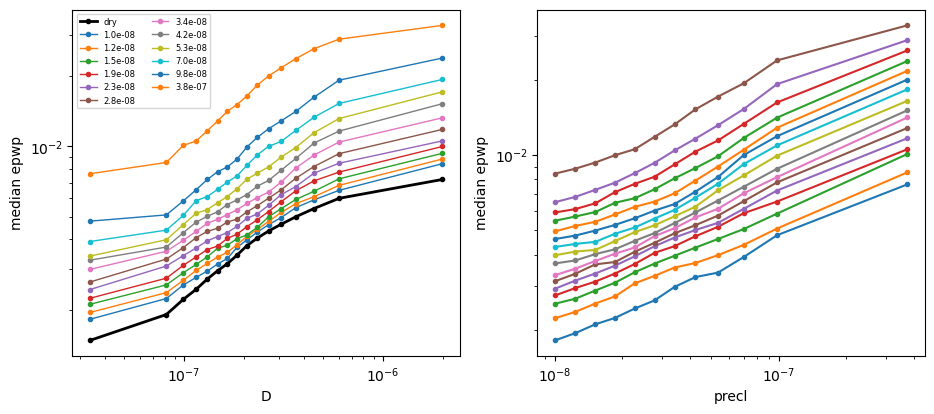

In [23]:
dc = np.sqrt(d_edges[:-1] * d_edges[1:])
pc = np.sqrt(np.maximum(p_edges[:-1], p_dry) * p_edges[1:])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for j in range(med.shape[1]):
    ax[0].plot(dc, med[:, j], marker='o', ms=3, lw=2 if j == 0 else 1,
               color='k' if j == 0 else None,
               label='dry' if j == 0 else f'{pc[j]:.1e}')
ax[0].set(xscale='log', yscale='log', xlabel='D', ylabel='median epwp')
ax[0].legend(fontsize=6, ncol=2)
for i in range(med.shape[0]):
    ax[1].plot(pc[1:], med[i, 1:], marker='o', ms=3)
ax[1].set(xscale='log', yscale='log', xlabel='precl', ylabel='median epwp')

In [24]:
sp=DF.cell_spread(dd, pp, yy, d_edges, p_edges, min_count=200, p_dry=p_dry)

cells used:          208 of 208
within-cell  var:    0.8290  (log units)
between-cell var:    0.4145
explained fraction:  0.333
ceiling on log-r:    0.577
median 16–84 spread: 5.26x


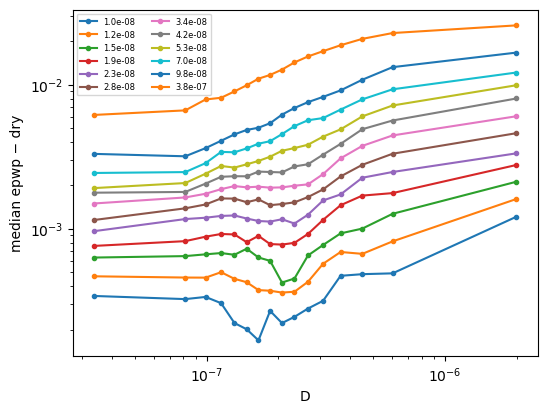

In [25]:
diff = med[:, 1:] - med[:, [0]]        # linear space, not log

fig, ax = plt.subplots(figsize=(6, 4.5))
for j in range(diff.shape[1]):
    ax.plot(dc, diff[:, j], marker='o', ms=3, label=f'{pc[j+1]:.1e}')
ax.set(xscale='log', yscale='log', xlabel='D', ylabel='median epwp − dry')
ax.legend(fontsize=6, ncol=2)

NNLS grid: 45375 nodes on 100000 points
NNLS grid best fit:
  y0  = 0
  A   = 0.0566274
  a   = 1.5
  D0  = 4.75468e-08
  B   = 0.00261511
  b   = 1.1
  c   = 0.3
  residual = 4.26053
Log-space polish:
  y0  = 0   (NNLS: 0)  [fixed]
  A   = 0.0286434   (NNLS: 0.0566274)
  a   = 1.37171   (NNLS: 1.5)
  D0  = 5.35485e-08   (NNLS: 4.75468e-08)
  B   = 0.00236692   (NNLS: 0.00261511)
  b   = 1.05873   (NNLS: 1.1)
  c   = 0.582212   (NNLS: 0.3)
  cost = 1.26008e+06,  success = True
--- SH fit ---
  r_full (log)     = 0.5813
  pred/obs median  = 1.009   16-84%: 0.423-2.333
  implied sigma    = 0.854  (log units, for stochastic)
  r_form (surface) = 0.9712  [count-weighted]
residual map: 208 of 208 cells
  spread (std over cells)      = 0.0524
  max |median residual|        = 0.1736
  count-weighted mean |res|    = 0.0353
  fraction of points |res|>0.3 = 0.000
  Spearman vs D bin = +0.274
  Spearman vs P bin = -0.329


<Axes: xlabel='log10 precl', ylabel='log10 D'>

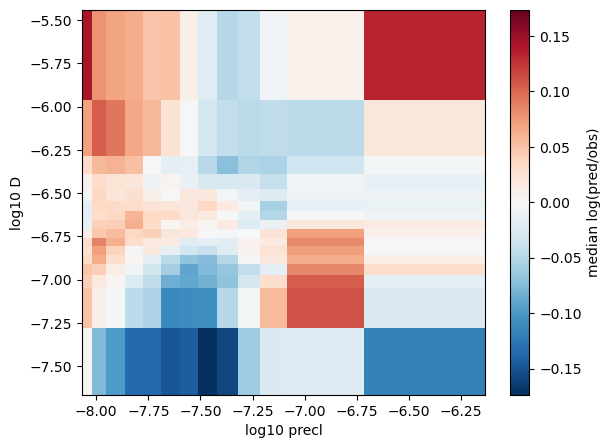

In [31]:
import importlib, source_fit_refvals as SF
importlib.reload(SF)

use_y0=False
g7 = SF.fit_nnls_grid(dd, pp, yy, use_y0=use_y0)
par, out = SF.fit_log_polish(dd, pp, yy, g7['params'] , use_y0=use_y0)
SF.score(dd, pp, yy, par, med=med, dc=dc, pc=pc, cnt=cnt, label='SH fit')
res, rcnt = SF.residual_map(dd, pp, yy, par, d_edges, p_edges)
SF.plot_residual_map(res, dc, pc)

In [ ]:
print( poopypants )

"""
# - Skip this
import importlib, source_fit as SF
importlib.reload(SF)

g6 = SF.fit_nnls_grid(dd, pp, yy, use_y0=False, c_grid=[0.0] )
par, _ = SF.fit_log_polish(dd, pp, yy, g['params'] , use_y0=False, fix_c=True )
SF.score(dd, pp, yy, par, med=med, dc=dc, pc=pc, cnt=cnt, label='SH fit')
res, rcnt = SF.residual_map(dd, pp, yy, par, d_edges, p_edges)
SF.plot_residual_map(res, dc, pc)
"""

NNLS grid: 4125 nodes on 100000 points
NNLS grid best fit:
  y0  = 0
  A   = 0.0406283
  a   = 1.5
  D0  = 7.53566e-08
  B   = 0.00209766
  b   = 1.2
  c   = 0
  residual = 4.2751
Log-space polish:
  y0  = 0   (NNLS: 0)  [fixed]
  A   = 0.0405868   (NNLS: 0.0566274)
  a   = 1.48523   (NNLS: 1.5)
  D0  = 3.73564e-08   (NNLS: 4.75468e-08)
  B   = 0.00205079   (NNLS: 0.00261511)
  b   = 1.12204   (NNLS: 1.1)
  c   = 0.3   (NNLS: 0.3)  [fixed]
  cost = 1.26372e+06,  success = True
--- SH fit ---
  r_full (log)     = 0.5795
  pred/obs median  = 1.007   16-84%: 0.423-2.345
  implied sigma    = 0.856  (log units, for stochastic)
  r_form (surface) = 0.9679  [count-weighted]
residual map: 208 of 208 cells
  spread (std over cells)      = 0.0832
  max |median residual|        = 0.3091
  count-weighted mean |res|    = 0.0487
  fraction of points |res|>0.3 = 0.001
  Spearman vs D bin = -0.217
  Spearman vs P bin = -0.120


<Axes: xlabel='log10 precl', ylabel='log10 D'>

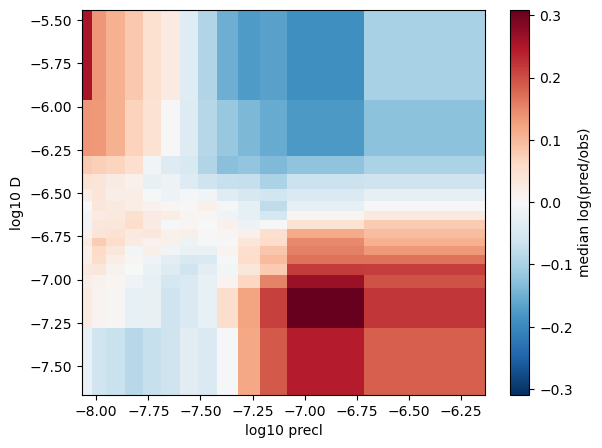

In [32]:
import importlib, source_fit_refvals as SF
importlib.reload(SF)

use_y0=False
g6 = SF.fit_nnls_grid(dd, pp, yy, use_y0=use_y0, c_grid=[0.0] )
par, _ = SF.fit_log_polish(dd, pp, yy, g['params'] , use_y0=use_y0, fix_c=True )
SF.score(dd, pp, yy, par, med=med, dc=dc, pc=pc, cnt=cnt, label='SH fit')
res, rcnt = SF.residual_map(dd, pp, yy, par, d_edges, p_edges)
SF.plot_residual_map(res, dc, pc)

{'y0': np.float64(0.0), 'A': np.float64(0.05662744099311622), 'a': np.float64(1.5), 'D0': np.float64(4.754679577383344e-08), 'B': np.float64(0.002615114957098987), 'b': np.float64(1.0999999999999999), 'c': np.float64(0.30000000000000004)}
0.0
0.5783581082929715


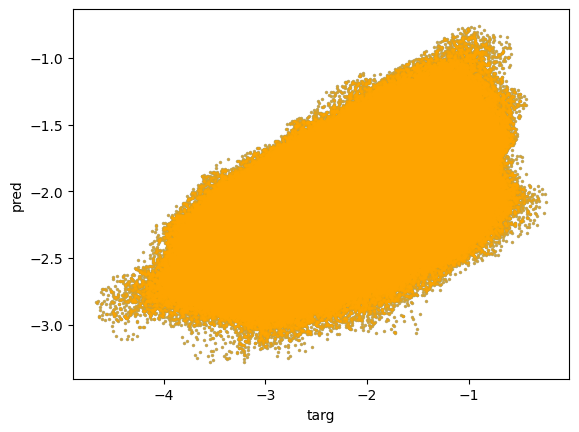

In [33]:
print(g7['params'])
pa=AttrDict(g7['params'])
print( pa.y0 )


epwp_pred = SF.source_model(dd, pp, pa.y0, pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)
epwp_pred_2 = SF.source_model(dd, pp, 0. , pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)

fig, ax = plt.subplots()

ax.scatter(np.log10(yy+1.e-12) ,
           np.log10(epwp_pred+1.e-12) ,
           s=2, alpha=0.5)
ax.scatter(np.log10(yy+1.e-12) ,
           np.log10(epwp_pred_2+1.e-12) ,
           s=2, alpha=0.5,c='orange')

ax.set_xlabel('targ')
ax.set_ylabel('pred')



r_transfer = np.corrcoef(np.log(epwp_pred), np.log(yy))[0, 1]

print( r_transfer)

In [34]:
print( pa )
#epwp_pred_yx = SF.source_model( D, P, pa.y0, pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)
epwp_pred_yx = SF.source_model( D, P, pa.y0, pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)
epwp_pred_yx.shape

{'y0': np.float64(0.0), 'A': np.float64(0.05662744099311622), 'a': np.float64(1.5), 'D0': np.float64(4.754679577383344e-08), 'B': np.float64(0.002615114957098987), 'b': np.float64(1.0999999999999999), 'c': np.float64(0.30000000000000004)}


(247, 192, 288)

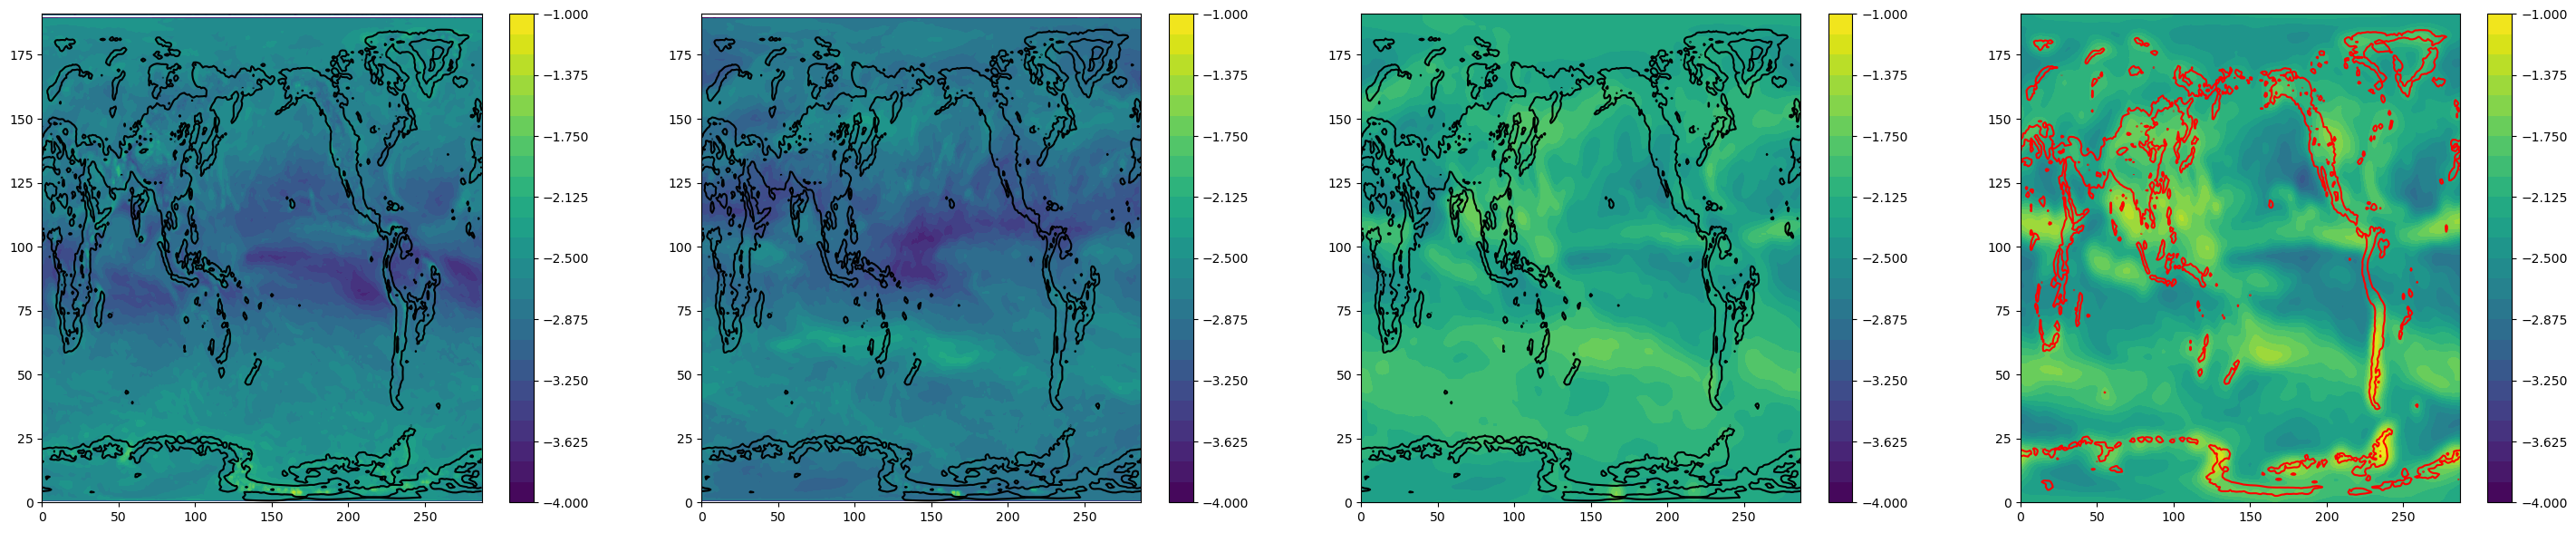

In [35]:
from scipy.ndimage import gaussian_filter

#smoothed = gaussian_filter(field, sigma=2)  # sigma in grid points

logmflv = np.linspace( -4,-1, num=25 )

sgh_smooth = gaussian_filter( sgh, sigma=0) 
#mxd_smooth = gaussian_filter( A.mxdis, sigma=1) 
t=100
t0,t1=0,247 #100,100
#xpwp_src_3_1.shape
fig,axs=plt.subplots( 1,4, figsize=(4*9,7) ) 
ax=axs[2]
co=ax.contourf(  np.log10( epwp_pred_yx[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[3]
co=ax.contourf(   np.log10( Y[t0:t1+1,:,:].mean( axis=0)  ) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( sgh_smooth , levels=[200, 2000] , colors='red' )
plt.colorbar( co )
ax=axs[1]
co=ax.contourf(  np.log10( xpwp_src_3_1[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[0]
co=ax.contourf(  np.log10( xpwp_src_1_2[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )


In [ ]:
plt.plot( lat, np.mean( epwp_pred_yx[t0:t1+1,:,:] , axis=(0,2) ) )
#plt.plot( lat, np.mean( Y[t0:t1+1,:,:] , axis=(0,2) ) )
plt.plot( lat, np.mean( 4*xpwp_src_3_1[t0:t1+1,:,:] , axis=(0,2) ) )


In [ ]:
print( poopypants )

In [ ]:
#NH transfer

plt.contour( maskN )

P=precl
D=tilt_zs_zl
Y=epwp_zl
D, P, Y = ( gaussian_filter( Q ,sigma=(0,2,2) ,mode=('reflect','reflect','wrap'))    for Q in (D, P, Y))

ddN , ppN , yyN = (  Q[:, maskN].ravel()   for Q in (D,P, Y) )



In [ ]:
par6 = g6['params']


s6 = SF.score(dd, pp, yy, par6, label='6-param, SH-fit ')
s6N = SF.score(ddN, ppN, yyN, par6, label='6-param, SH-fit -> NH')


In [ ]:
v = np.nanmax(np.abs(res))
plt.pcolormesh(np.log10(pc), np.log10(dc), res, cmap='RdBu_r',
               vmin=-v, vmax=v, shading='nearest')
plt.colorbar(label='median log(pred/obs)')
plt.xlabel('log10 precl'); plt.ylabel('log10 D')

In [ ]:
sp['cell_var'].shape

In [ ]:
dc = np.sqrt(d_edges[:-1] * d_edges[1:])
pc = np.sqrt(np.maximum(p_edges[:-1], p_dry) * p_edges[1:])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for j in range(med.shape[1]):
    ax[0].plot(dc, med[:, j], marker='o', ms=3, lw=2 if j == 0 else 1,
               color='k' if j == 0 else None,
               label='dry' if j == 0 else f'{pc[j]:.1e}')
ax[0].set(xscale='log', yscale='log', xlabel='D', ylabel='median epwp')
ax[0].legend(fontsize=6, ncol=2)
for i in range(med.shape[0]):
    ax[1].plot(pc[1:], med[i, 1:], marker='o', ms=3)
ax[1].set(xscale='log', yscale='log', xlabel='precl', ylabel='median epwp')

In [ ]:
plt.contourf( np.log10(med) )

In [ ]:

# drop the dry column — log(P) is undefined there, and it's a
# qualitatively different class anyway. Keep it in mind separately.
Z = np.log10(med[:, 1:])
X = np.log10(pc[1:])      # log precl, bin centres
Y = np.log10(dc)          # log D, bin centres

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

im = ax[0].pcolormesh(X, Y, Z, shading='nearest', cmap='viridis')
cs = ax[0].contour(X, Y, Z, levels=12, colors='k', linewidths=0.5)
ax[0].clabel(cs, fontsize=6, fmt='%.2f')
ax[0].set(xlabel='log10 precl', ylabel='log10 D',
          title='log10 median epwp')
fig.colorbar(im, ax=ax[0])

# same surface with the dry-column baseline removed
im2 = ax[1].pcolormesh(X, Y, med[:, 1:] - med[:, [0]],
                       shading='nearest', cmap='magma')
ax[1].set(xlabel='log10 precl', ylabel='log10 D',
          title='median epwp − dry (linear)')
fig.colorbar(im2, ax=ax[1])
plt.tight_layout()

In [ ]:
print(med.shape)
from mpl_toolkits.mplot3d import Axes3D
XX, YY = np.meshgrid(X, Y)
fig = plt.figure(figsize=(7, 6))
ax3 = fig.add_subplot(111, projection='3d')
ax3.plot_surface(XX, YY, Z, cmap='viridis', edgecolor='k', lw=0.2)
ax3.set(xlabel='log10 precl', ylabel='log10 D', zlabel='log10 epwp')

In [ ]:
fig, ax = plt.subplots()

ax.scatter(dd,
           yy,
           s=5, alpha=0.5)

#ax.scatter(D[:, mask].ravel(),
#           Y[:, mask].ravel(),
#           s=5, alpha=0.5)

ax.set_xlabel('Pred')
ax.set_ylabel('epwp')

In [ ]:
#B,A = epwp_zl,tilt_zs 
#B,A = gaussian_filter( epwp_zl,2) ,gaussian_filter( tilt_zs ,2)
B = gaussian_filter( epwp_zl,sigma=(0,2,2) ,mode=('reflect','reflect','wrap')) 
A = gaussian_filter( tilt_zs,sigma=(0,2,2) ,mode=('reflect','reflect','wrap')) 
#B,A = GWP.precl.values,tilt_zl
#gaussian_filter( sgh, sigma=2)

A=np.log10( A + 1.e-16)
B=np.log10( B + 1.e-16 )

In [ ]:
fig, ax = plt.subplots()

ax.scatter(A[:, mask].ravel(),
           B[:, mask].ravel(),
           s=5, alpha=0.5)

ax.set_xlabel('A')
ax.set_ylabel('epwp')

In [ ]:
aa = A[:, mask].ravel()
bb = B[:, mask].ravel()

good = np.isfinite(aa) & np.isfinite(bb)

##ax.scatter(aa[good], bb[good], s=5, alpha=0.5)

In [ ]:
from matplotlib.colors import LogNorm



fig, ax = plt.subplots()

h = ax.hist2d(
    aa[good],
    bb[good],
    bins=50,
    norm=LogNorm()
)

fig.colorbar(h[3], ax=ax, label='Count')

ax.set_xlabel('A')
ax.set_ylabel('epwp')